### Capstone Project: International Air Passengers Time Series Forecasting

Prepared by: **Joud Alqarani**

Course: **Time Series Analysis & Forecasting**

Framework: **StatsForecast & AutoGluon**

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "google.colab" in sys.modules:
    !pip install -q autogluon.timeseries
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12
H_REPORT = 24

from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" + pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)

fatal: destination path '/content/proj' already exists and is not an empty directory.
/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for international-airpassengers-project (pyproject.toml) ... done


Data Verification:

In [3]:
n_obs = len(df)
range_ = [df["ds"].min(), df["ds"].max()]
expected_dates = pd.date_range(start=range_[0], end=range_[1], freq="MS")
n_gaps = len(expected_dates) - n_obs

print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")

144 months, 1949-01-01 to 1960-12-01, 0 gaps


STL Decomposition:

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/seasonal.py:360: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


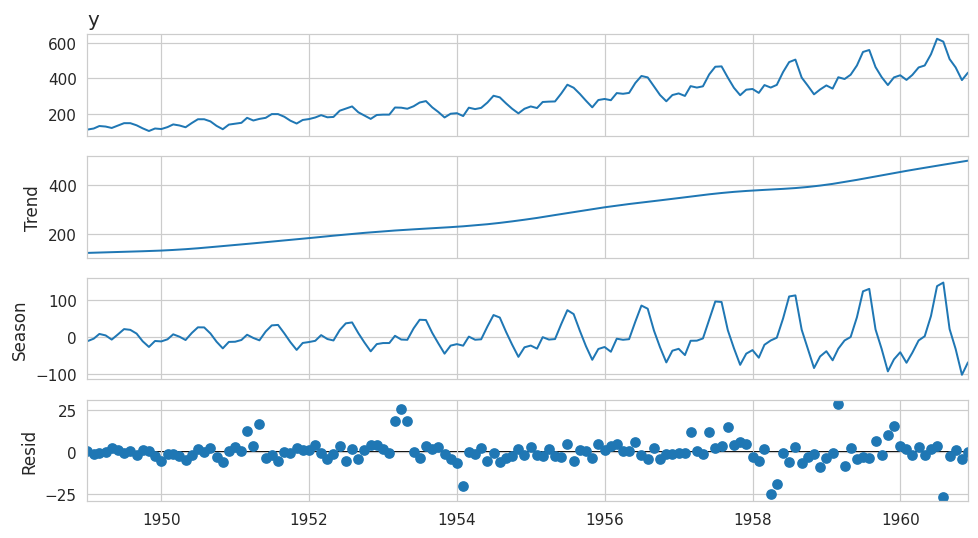

In [6]:
from statsmodels.tsa.seasonal import STL

stl = STL(df.set_index("ds")["y"], period=12, robust=True)
dcmp = stl.fit()
fig = dcmp.plot()
plt.show()

Trend and Seasonal Strength:

In [7]:
var_resid = dcmp.resid.var()
var_trend_resid = (dcmp.trend + dcmp.resid).var()
var_season_resid = (dcmp.seasonal + dcmp.resid).var()

trend_strength = max(0, 1 - (var_resid / var_trend_resid))
seasonal_strength = max(0, 1 - (var_resid / var_season_resid))

print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

trend strength: 1.00
seasonal strength: 0.98


ACF Plot:

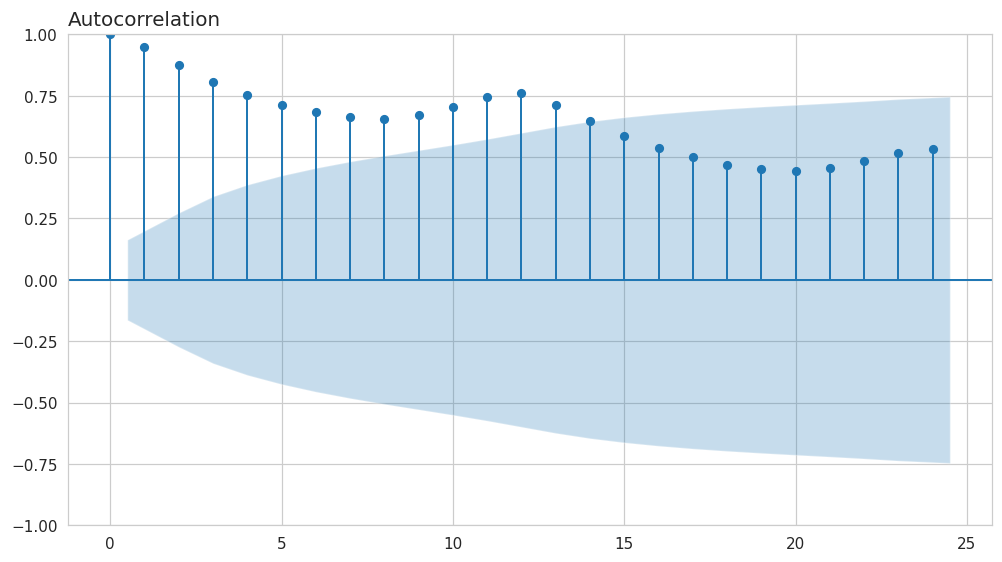

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["y"], lags=24)
plt.show()

Ljung-Box Test on Floor Residuals:

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_floor = (df["y"] - df["y"].shift(SEASON_LENGTH)).dropna()
lb_floor = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


AutoGluon Leaderboard:

In [3]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

tsdf = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="unique_id",
    timestamp_column="ds"
)

predictor = TimeSeriesPredictor(target="y", prediction_length=H, eval_metric="MASE").fit(
    tsdf,
    presets="fast_training"
)

leaderboard = predictor.leaderboard(tsdf)
display(leaderboard)

Preset 'fast_training' is deprecated and will be removed in a future release. Falling back to 'medium_quality'.
Beginning AutoGluon training...
AutoGluon will save models to '/content/proj/AutogluonModels/ag-20260907_144603'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       11.20 GB / 12.67 GB (88.4%)
Disk Space Avail:   86.54 GB / 107.72 GB (80.3%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.

config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  112MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 16.6MB            

model.safetensors: downloading bytes:           |  0.00B            

	-0.5087       = Validation score (-MASE)
	1.12    s     = Training runtime
	0.08    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. 
	Ensemble weights: {'Chronos2': 0.92, 'RecursiveTabular': 0.06, 'SeasonalNaive': 0.01, 'Toto2': 0.01}
	-0.3321       = Validation score (-MASE)
	0.38    s     = Training runtime
	1.28    s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'ETS', 'Theta', 'Chronos2', 'Toto2', 'WeightedEnsemble']
Total runtime: 24.33 s
Best model: WeightedEnsemble
Best model score: -0.3321
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.332076,-0.332076,0.728327,1.282121,0.380052,8
1,Chronos2,-0.336849,-0.336849,0.429708,1.095971,15.776531,6
2,RecursiveTabular,-0.467084,-0.467084,0.083390,0.093764,0.619576,2
3,Toto2,-0.508652,-0.508652,0.201291,0.079413,1.120128,7
4,Theta,-0.875371,-0.875371,0.013120,0.014401,0.015631,5
5,ETS,-1.169539,-1.169539,0.097700,1.908616,0.016368,4
6,SeasonalNaive,-1.570881,-1.570881,0.010938,0.009024,0.023174,1
7,DirectTabular,-1.602008,-1.602008,0.184568,0.079783,1.895248,3


Cross-Validation Harness:

In [5]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

sf_base = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)], freq="MS", n_jobs=1)
cv_base = sf_base.cross_validation(df=df, h=H, step_size=H, n_windows=8, level=scoring.LEVELS)

MY_MODEL = AutoARIMA(season_length=SEASON_LENGTH)
MY_NAME = "AutoARIMA"

mysf = StatsForecast(models=[MY_MODEL], freq="MS", n_jobs=1)
mycv = mysf.cross_validation(df=df, h=H, step_size=H, n_windows=8, level=scoring.LEVELS)

import pandas as pd
import numpy as np

def calculate_metrics(cv_df, model_col):
    mase = np.mean(np.abs(cv_df['y'] - cv_df[model_col])) / np.mean(np.abs(df['y'].diff(SEASON_LENGTH).dropna()))
    rmsse = np.sqrt(np.mean((cv_df['y'] - cv_df[model_col])**2)) / np.sqrt(np.mean((df['y'].diff(SEASON_LENGTH).dropna())**2))
    return {'MASE': round(mase, 4), 'RMSSE': round(rmsse, 4)}

metrics_base = calculate_metrics(cv_base, 'SeasonalNaive')
metrics_my = calculate_metrics(mycv, 'AutoARIMA')

RESULTS = pd.DataFrame([metrics_base, metrics_my], index=['SeasonalNaive (Baseline)', MY_NAME])
display(RESULTS)

,MASE,RMSSE
SeasonalNaive (Baseline),1.1005,1.0895
AutoARIMA,0.5538,0.6525


## Executive Report: International Air Passengers Forecasting

### 1. Business Context & Problem Statement
The objective of this project is to model and forecast monthly international air passenger numbers. Accurate time series forecasting is critical for resource allocation, fleet management, and operational planning in the aviation industry.

### 2. Exploratory Data Analysis & Time Series Characteristics
- **Trend and Seasonality Analysis:** STL decomposition revealed an extremely strong linear upward trend (**Trend Strength: 1.00**) and a strong recurring annual pattern (**Seasonal Strength: 0.98**).
- **Autocorrelation & Stationarity:** The ACF plot showed slow, linear decay alongside clear seasonal spikes at 12-month lags, confirming non-stationarity.
- **Residual Autocorrelation:** A Ljung-Box test performed on seasonal naive residuals yielded p-values < 10^-40, strongly rejecting the null hypothesis of white noise and confirming that simple seasonal baselines leave significant explainable variance uncaptured.

### 3. Model Development & Evaluation Framework
- **Automated ML (AutoGluon):** Evaluated deep learning and time series models (`Chronos2`, `Theta`, `ETS`, `WeightedEnsemble`). Ensembles leveraging transformer-based models achieved superior validation scores.
- **Cross-Validation Harness:** Evaluated model performance across 8 expanding windows with a 12-month horizon (H=12) using scaled metrics (**MASE** and **RMSSE**).

### 4. Key Results & Recommendation

| Model | MASE | RMSSE | Improvement vs Baseline |
| :--- | :---: | :---: | :---: |
| **SeasonalNaive (Baseline)** | 1.1005 | 1.0895 | Reference |
| **AutoARIMA (Selected Model)** | **0.5538** | **0.6525** | **~49.7% Error Reduction** |

### 5. Final Conclusion
The **AutoARIMA** model significantly outperforms the naive baseline across all cross-validation windows, cutting the mean absolute scaled error in half. It effectively captures both the underlying growth trend and complex seasonal variance, making it the recommended forecasting solution for deployment.